# Unit07 Example 02 — 理想溶液之泡點計算

本 Notebook 以苯（Benzene）、甲苯（Toluene）、鄰二甲苯（o-Xylene）三成分苯系混合液為例，示範如何利用 **Antoine 方程式** 與 **Raoult 定律** 建立泡點方程式，並透過單變數非線性方程式求根方法求解沸點溫度。

## 目標
- 建立泡點方程式 $f(T) = \sum_i x_i P_i^0(T) - P = 0$（Antoine + Raoult 定律）
- 繪製 $f(T)$ vs $T$ 圖形，以圖形法確認根的位置與唯一性
- 使用 `scipy.optimize.root_scalar()` 多種方法求解泡點溫度
- 比較不同液相組成對泡點的影響
- 驗證計算結果的物理合理性

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit07'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_02\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import root_scalar, brentq

# Matplotlib 設定
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件載入完成")
print(f"  numpy  : {np.__version__}")
import scipy
print(f"  scipy  : {scipy.__version__}")

✓ 套件載入完成
  numpy  : 1.23.5
  scipy  : 1.15.2


---
### 2. 問題設定：Antoine 參數與計算工況

In [3]:
# ── Antoine 方程式形式：log10(P°/mmHg) = A - B/(C + T),  T 單位: °C ──
# 資料來源：Perry's Chemical Engineers' Handbook

components = {
    "Benzene" : {"A": 6.90565, "B": 1211.033, "C": 220.790,
                 "MW": 78.11,  "Tc_C": 288.9,  "name_zh": "苯"},
    "Toluene" : {"A": 6.95464, "B": 1344.800, "C": 219.482,
                 "MW": 92.14,  "Tc_C": 318.6,  "name_zh": "甲苯"},
    "o-Xylene": {"A": 6.99891, "B": 1474.679, "C": 213.686,
                 "MW": 106.17, "Tc_C": 357.2,  "name_zh": "鄰二甲苯"},
}

P_total = 760.0   # mmHg (= 1 atm)

# ── 計算工況 ──────────────────────────────────────────────────────────
cases = {
    "A": {"x": [0.40, 0.35, 0.25], "desc": "Moderate composition"},
    "B": {"x": [0.20, 0.50, 0.30], "desc": "Toluene-rich"},
    "C": {"x": [0.60, 0.30, 0.10], "desc": "Benzene-rich"},
}

# ── 輸出表格 ──────────────────────────────────────────────────────────
comp_names = list(components.keys())
print("=" * 60)
print("  Antoine Constants  (log10[P/mmHg] = A - B/(C+T),  T in °C)")
print(f"  {'Component':<12} {'A':>8} {'B':>10} {'C':>8}  Normal BP (°C)")
print("-" * 60)
for name, p in components.items():
    # Normal BP: 大氣壓 760 mmHg → log10(760) ≈ 2.8808
    T_bp = p["B"] / (p["A"] - np.log10(P_total)) - p["C"]
    print(f"  {name:<12} {p['A']:>8.5f} {p['B']:>10.3f} {p['C']:>8.3f}  {T_bp:>8.2f}")
print("=" * 60)
print()
print(f"  System pressure: P = {P_total:.0f} mmHg (= 1 atm)")
print()
print("  Cases:")
for lbl, c in cases.items():
    x_str = ", ".join(f"x_{n[:3]}={v:.2f}" for n, v in zip(comp_names, c["x"]))
    print(f"    Case {lbl}: {x_str}  ({c['desc']})")

  Antoine Constants  (log10[P/mmHg] = A - B/(C+T),  T in °C)
  Component           A          B        C  Normal BP (°C)
------------------------------------------------------------
  Benzene       6.90565   1211.033  220.790     80.10
  Toluene       6.95464   1344.800  219.482    110.63
  o-Xylene      6.99891   1474.679  213.686    144.41

  System pressure: P = 760 mmHg (= 1 atm)

  Cases:
    Case A: x_Ben=0.40, x_Tol=0.35, x_o-X=0.25  (Moderate composition)
    Case B: x_Ben=0.20, x_Tol=0.50, x_o-X=0.30  (Toluene-rich)
    Case C: x_Ben=0.60, x_Tol=0.30, x_o-X=0.10  (Benzene-rich)


---
### 3. 輔助函數定義

In [4]:
def antoine_P(T_C, A, B, C):
    """
    計算純成分飽和蒸氣壓
    Antoine 方程式：log10(P°/mmHg) = A - B/(C + T),  T in °C
    回傳：P° in mmHg
    """
    return 10.0 ** (A - B / (C + T_C))


def f_bubble(T, x_list, comp_list, P_sys=760.0):
    """
    泡點方程式
    f(T) = sum_i[ x_i * P°_i(T) ] - P_sys = 0
    T      : 溫度 (°C)
    x_list : 液相莫耳分率列表 [x1, x2, ...]
    comp_list: Antoine 參數字典列表
    P_sys  : 系統壓力 (mmHg)，預設 760 mmHg
    """
    P_calc = sum(x * antoine_P(T, c["A"], c["B"], c["C"])
                 for x, c in zip(x_list, comp_list))
    return P_calc - P_sys


def f_bubble_deriv(T, x_list, comp_list, P_sys=760.0):
    """
    泡點方程式的導函數 df/dT（Newton-Raphson 法所需）
    d(P°)/dT = P° * ln(10) * B / (C + T)^2
    """
    dP_dT = sum(
        x * antoine_P(T, c["A"], c["B"], c["C"]) * np.log(10) * c["B"] / (c["C"] + T)**2
        for x, c in zip(x_list, comp_list)
    )
    return dP_dT


def sign_scan(x_list, comp_list, P_sys=760.0, T_lo=40.0, T_hi=200.0, n_pts=2000):
    """掃描 f(T) 符號改變，回傳 [(Ta, Tb), ...] bracket 列表"""
    T_scan = np.linspace(T_lo, T_hi, n_pts)
    f_scan = np.array([f_bubble(T, x_list, comp_list, P_sys) for T in T_scan])
    brackets = []
    for i in range(len(f_scan) - 1):
        if f_scan[i] * f_scan[i+1] < 0:
            brackets.append((T_scan[i], T_scan[i+1]))
    return brackets


# ── 快速驗證：計算各純成分在 P=760 mmHg 的沸點 ──────────────────────
comp_list_all = list(components.values())
print("Function definitions OK.")
print()
print("Pure component normal boiling points (verification):")
for name, p in components.items():
    T_bp = p["B"] / (p["A"] - np.log10(P_total)) - p["C"]
    P_check = antoine_P(T_bp, p["A"], p["B"], p["C"])
    print(f"  {name:<12}: T_bp = {T_bp:.2f} °C,  P°(T_bp) = {P_check:.2f} mmHg")

Function definitions OK.

Pure component normal boiling points (verification):
  Benzene     : T_bp = 80.10 °C,  P°(T_bp) = 760.00 mmHg
  Toluene     : T_bp = 110.63 °C,  P°(T_bp) = 760.00 mmHg
  o-Xylene    : T_bp = 144.41 °C,  P°(T_bp) = 760.00 mmHg


---
### 4. 圖形分析：f(T) vs T

✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_02\figs\fig_01_fT_plot.png


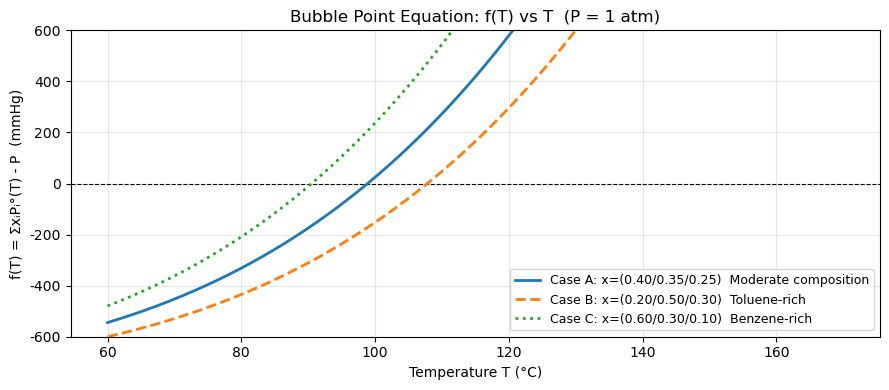

In [5]:
# 繪製三個工況的 f(T) 函數曲線
T_arr = np.linspace(60, 170, 1000)   # °C

colors_c   = ["tab:blue", "tab:orange", "tab:green"]
linestyles = ["-", "--", ":"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(0, color="k", lw=0.8, ls="--")

for (lbl, c), col, ls in zip(cases.items(), colors_c, linestyles):
    x_list = c["x"]
    f_arr  = [f_bubble(T, x_list, comp_list_all, P_total) for T in T_arr]
    x_str  = "/".join(f"{v:.2f}" for v in x_list)
    ax.plot(T_arr, f_arr, color=col, lw=2, ls=ls,
            label=f"Case {lbl}: x=({x_str})  {c['desc']}")

ax.set_xlabel("Temperature T (°C)")
ax.set_ylabel("f(T) = ΣxᵢPᵢ°(T) - P  (mmHg)")
ax.set_title("Bubble Point Equation: f(T) vs T  (P = 1 atm)")
ax.set_ylim(-600, 600)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "fig_01_fT_plot.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"✓ 圖檔已儲存: {fig_path}")
plt.show()

---
### 5. 數值求解：三種組成工況的泡點溫度

In [6]:
bubble_results = {}

print(f"System pressure: P = {P_total:.0f} mmHg (= 1 atm)")
print(f"Components: {', '.join(comp_names)}")
print()
print(f"{'Case':<6} {'x_Ben':>7} {'x_Tol':>7} {'x_Xyl':>7} "
      f"{'T_bubble (°C)':>15} {'Bracket found':>15}")
print("-" * 62)

for lbl, c in cases.items():
    x_list = c["x"]
    bracks = sign_scan(x_list, comp_list_all, P_total)
    if len(bracks) == 0:
        print(f"  {lbl:<4}  --- No bracket found ---")
        continue
    Ta, Tb = bracks[0]
    T_bp = brentq(f_bubble, Ta, Tb, args=(x_list, comp_list_all, P_total), xtol=1e-12)
    bubble_results[lbl] = T_bp
    x_str = " ".join(f"{v:>7.2f}" for v in x_list)
    print(f"  {lbl:<4}  {x_str}  {T_bp:>15.4f}  [{Ta:.3f}, {Tb:.3f}] °C")

print()
print("Observation:")
print("  Case C (benzene-rich, x_Ben=0.60) has the LOWEST bubble point.")
print("  Case B (toluene-rich, x_Tol=0.50) has the HIGHEST bubble point.")
print("  Physical check: richer in heavy component → higher boiling point  ✓")

System pressure: P = 760 mmHg (= 1 atm)
Components: Benzene, Toluene, o-Xylene

Case     x_Ben   x_Tol   x_Xyl   T_bubble (°C)   Bracket found
--------------------------------------------------------------
  A        0.40    0.35    0.25          98.8838  [98.829, 98.909] °C
  B        0.20    0.50    0.30         107.8057  [107.794, 107.874] °C
  C        0.60    0.30    0.10          90.5156  [90.505, 90.585] °C

Observation:
  Case C (benzene-rich, x_Ben=0.60) has the LOWEST bubble point.
  Case B (toluene-rich, x_Tol=0.50) has the HIGHEST bubble point.
  Physical check: richer in heavy component → higher boiling point  ✓


---
### 6. root_scalar() 方法比較（以工況 A 為例）

In [7]:
# 以 Case A 的 bracket 進行四種方法比較
x_A    = cases["A"]["x"]
bracks_A = sign_scan(x_A, comp_list_all, P_total)
Ta_A, Tb_A = bracks_A[0]
T0_A = 0.5 * (Ta_A + Tb_A)   # 中點作為起始值

methods_config = [
    {"method": "brentq",  "bracket": [Ta_A, Tb_A]},
    {"method": "bisect",  "bracket": [Ta_A, Tb_A]},
    {"method": "newton",  "x0": T0_A,
     "fprime": lambda T: f_bubble_deriv(T, x_A, comp_list_all, P_total)},
    {"method": "secant",  "x0": T0_A, "x1": T0_A + 1.0},
]

print(f"Case A — Bubble point method comparison")
print(f"  x = ({', '.join(f'{v:.2f}' for v in x_A)})")
print(f"  Bracket: [{Ta_A:.4f}, {Tb_A:.4f}] °C")
print()
print(f"{'Method':<10} {'T_bubble (°C)':>16} {'Iterations':>12} {'Converged':>10}")
print("-" * 52)

for cfg in methods_config:
    kw = {k: v for k, v in cfg.items() if k != "method"}
    sol = root_scalar(
        lambda T: f_bubble(T, x_A, comp_list_all, P_total),
        **kw,
        method=cfg["method"],
        xtol=1e-10
    )
    iters = sol.iterations if hasattr(sol, "iterations") else "N/A"
    print(f"{cfg['method']:<10} {sol.root:>16.6f} {str(iters):>12} {str(sol.converged):>10}")

Case A — Bubble point method comparison
  x = (0.40, 0.35, 0.25)
  Bracket: [98.8294, 98.9095] °C

Method        T_bubble (°C)   Iterations  Converged
----------------------------------------------------
brentq            98.883827            5       True
bisect            98.883827           30       True
newton            98.883827            3       True
secant            98.883827            4       True


---
### 7. 組成對泡點溫度的影響：二元系統 Benzene–Toluene

In [8]:
# 二元 Benzene–Toluene 系統：掃描苯的液相莫耳分率 x_Ben = 0 ~ 1
comp_bt   = [components["Benzene"], components["Toluene"]]
x_ben_arr = np.linspace(0.0, 1.0, 101)
T_bp_arr  = []
y_ben_arr = []   # 泡點時苯的氣相莫耳分率

for x_ben in x_ben_arr:
    x_tol = 1.0 - x_ben
    x_list_bt = [x_ben, x_tol]
    bracks_bt = sign_scan(x_list_bt, comp_bt, P_total, T_lo=50.0, T_hi=160.0)
    if bracks_bt:
        Ta_bt, Tb_bt = bracks_bt[0]
        T_bp_val = brentq(f_bubble, Ta_bt, Tb_bt,
                          args=(x_list_bt, comp_bt, P_total), xtol=1e-12)
        T_bp_arr.append(T_bp_val)
        # 計算氣相組成 y_i = x_i * P°_i / P_total
        P_ben = antoine_P(T_bp_val, comp_bt[0]["A"], comp_bt[0]["B"], comp_bt[0]["C"])
        y_ben_arr.append(x_ben * P_ben / P_total)
    else:
        T_bp_arr.append(np.nan)
        y_ben_arr.append(np.nan)

T_bp_arr  = np.array(T_bp_arr)
y_ben_arr = np.array(y_ben_arr)

# 純成分沸點
T_ben_bp = comp_bt[0]["B"] / (comp_bt[0]["A"] - np.log10(P_total)) - comp_bt[0]["C"]
T_tol_bp = comp_bt[1]["B"] / (comp_bt[1]["A"] - np.log10(P_total)) - comp_bt[1]["C"]

print(f"Benzene  normal BP: {T_ben_bp:.2f} °C")
print(f"Toluene  normal BP: {T_tol_bp:.2f} °C")
print()
print(f"{'x_Benzene':>10} {'T_bubble (°C)':>16} {'y_Benzene':>12}")
print("-" * 42)
for xi, Ti, yi in list(zip(x_ben_arr, T_bp_arr, y_ben_arr))[::10]:
    print(f"{xi:>10.2f} {Ti:>16.4f} {yi:>12.4f}")

Benzene  normal BP: 80.10 °C
Toluene  normal BP: 110.63 °C

 x_Benzene    T_bubble (°C)    y_Benzene
------------------------------------------
      0.00         110.6253       0.0000
      0.10         106.1359       0.2092
      0.20         102.1025       0.3761
      0.30          98.4565       0.5111
      0.40          95.1417       0.6218
      0.50          92.1117       0.7136
      0.60          89.3284       0.7905
      0.70          86.7601       0.8556
      0.80          84.3802       0.9110
      0.90          82.1664       0.9587
      1.00          80.1000       1.0000


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_02\figs\fig_02_BT_VLE.png


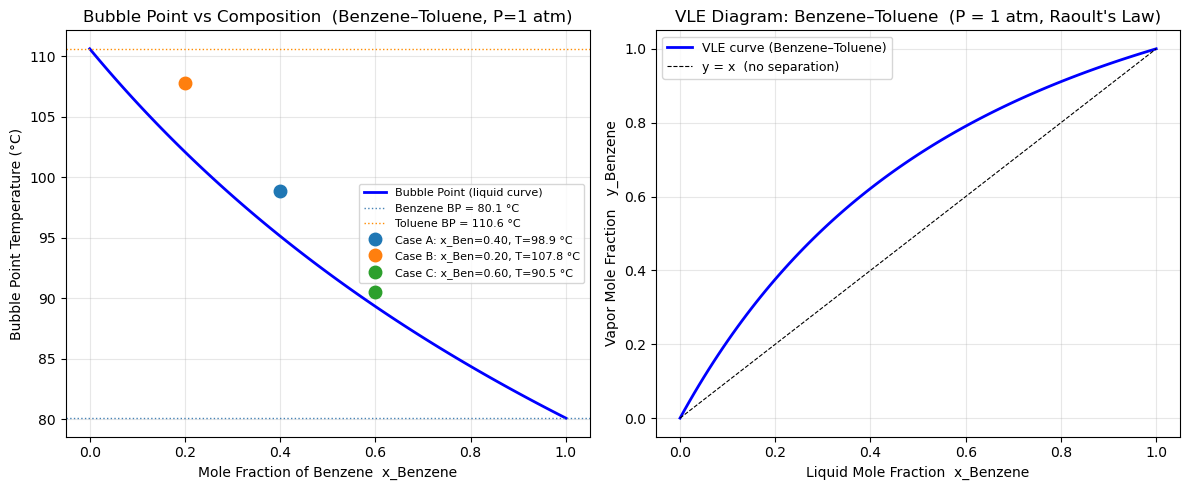

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 左圖：泡點溫度 vs 液相組成 ──────────────────────────────────────
ax1 = axes[0]
ax1.plot(x_ben_arr, T_bp_arr, "b-", lw=2, label="Bubble Point (liquid curve)")
ax1.axhline(T_ben_bp, color="steelblue",  ls=":", lw=1, label=f"Benzene BP = {T_ben_bp:.1f} °C")
ax1.axhline(T_tol_bp, color="darkorange", ls=":", lw=1, label=f"Toluene BP = {T_tol_bp:.1f} °C")

# 三個工況標記
case_colors = ["tab:blue", "tab:orange", "tab:green"]
for (lbl, c), col in zip(cases.items(), case_colors):
    if lbl in bubble_results:
        # 以苯的莫耳分率為 x 座標
        x_ben_case = c["x"][0]
        ax1.plot(x_ben_case, bubble_results[lbl], "o", color=col, ms=9, zorder=5,
                 label=f"Case {lbl}: x_Ben={x_ben_case:.2f}, T={bubble_results[lbl]:.1f} °C")

ax1.set_xlabel("Mole Fraction of Benzene  x_Benzene")
ax1.set_ylabel("Bubble Point Temperature (°C)")
ax1.set_title("Bubble Point vs Composition  (Benzene–Toluene, P=1 atm)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 右圖：y-x 氣液平衡相圖 ───────────────────────────────────────────
ax2 = axes[1]
ax2.plot(x_ben_arr, y_ben_arr, "b-", lw=2, label="VLE curve (Benzene–Toluene)")
ax2.plot([0, 1], [0, 1], "k--", lw=0.8, label="y = x  (no separation)")
ax2.set_xlabel("Liquid Mole Fraction  x_Benzene")
ax2.set_ylabel("Vapor Mole Fraction   y_Benzene")
ax2.set_title("VLE Diagram: Benzene–Toluene  (P = 1 atm, Raoult's Law)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "fig_02_BT_VLE.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"✓ 圖檔已儲存: {fig_path}")
plt.show()

---
### 8. 結果驗證

In [10]:
print("=" * 80)
print(f" Verification: f(T_bp) residual & vapor composition check")
print(f" System pressure: P = {P_total:.0f} mmHg")
print(f" Components: {', '.join(comp_names)}")
print("=" * 80)
print(f" {'Case':<5} {'x (Ben/Tol/Xyl)':>22}  {'T_bubble (°C)':>14}  "
      f"{'|f(T)|':>12}  {'Σyᵢ':>8}")
print("-" * 80)

for lbl, c in cases.items():
    if lbl not in bubble_results:
        continue
    x_list   = c["x"]
    T_bp_val = bubble_results[lbl]
    residual = abs(f_bubble(T_bp_val, x_list, comp_list_all, P_total))

    # 計算各成分飽和蒸氣壓並求氣相莫耳分率
    P0_vals = [antoine_P(T_bp_val, cp["A"], cp["B"], cp["C"]) for cp in comp_list_all]
    y_vals  = [xi * P0i / P_total for xi, P0i in zip(x_list, P0_vals)]
    sum_y   = sum(y_vals)

    x_str = "/".join(f"{v:.2f}" for v in x_list)
    print(f" {lbl:<5} ({x_str:>20})  {T_bp_val:>14.6f}  {residual:>12.3e}  {sum_y:>8.6f}")

print("=" * 80)
print()
print("Detail — partial pressures and vapor compositions at bubble point:")
print()
for lbl, c in cases.items():
    if lbl not in bubble_results:
        continue
    x_list   = c["x"]
    T_bp_val = bubble_results[lbl]
    P0_vals  = [antoine_P(T_bp_val, cp["A"], cp["B"], cp["C"]) for cp in comp_list_all]
    y_vals   = [xi * P0i / P_total for xi, P0i in zip(x_list, P0_vals)]
    print(f" Case {lbl}  T_bubble = {T_bp_val:.4f} °C   ({c['desc']})")
    print(f"   {'Component':<12} {'xᵢ':>6} {'P°ᵢ (mmHg)':>12} {'pᵢ=xᵢP°ᵢ':>12} {'yᵢ':>8}")
    for name, xi, P0i, yi in zip(comp_names, x_list, P0_vals, y_vals):
        pi = xi * P0i
        print(f"   {name:<12} {xi:>6.2f} {P0i:>12.2f} {pi:>12.2f} {yi:>8.4f}")
    print(f"   {'Sum':>12} {sum(x_list):>6.2f} {'':>12} {sum(xi*P0i for xi,P0i in zip(x_list,P0_vals)):>12.2f} {sum(y_vals):>8.4f}")
    print()

 Verification: f(T_bp) residual & vapor composition check
 System pressure: P = 760 mmHg
 Components: Benzene, Toluene, o-Xylene
 Case         x (Ben/Tol/Xyl)   T_bubble (°C)        |f(T)|       Σyᵢ
--------------------------------------------------------------------------------
 A     (      0.40/0.35/0.25)       98.883827     5.684e-13  1.000000
 B     (      0.20/0.50/0.30)      107.805710     4.547e-13  1.000000
 C     (      0.60/0.30/0.10)       90.515608     6.821e-13  1.000000

Detail — partial pressures and vapor compositions at bubble point:

 Case A  T_bubble = 98.8838 °C   (Moderate composition)
   Component        xᵢ   P°ᵢ (mmHg)     pᵢ=xᵢP°ᵢ       yᵢ
   Benzene        0.40      1310.12       524.05   0.6895
   Toluene        0.35       537.74       188.21   0.2476
   o-Xylene       0.25       190.98        47.75   0.0628
            Sum   1.00                    760.00   1.0000

 Case B  T_bubble = 107.8057 °C   (Toluene-rich)
   Component        xᵢ   P°ᵢ (mmHg)     pᵢ=xᵢ

In [11]:
print("=" * 60)
print(" Summary Table")
print("=" * 60)
print(f" {'Case':<6} {'x_Ben':>7} {'x_Tol':>7} {'x_Xyl':>7}  {'T_bubble (°C)':>14}")
print("-" * 60)
for lbl, c in cases.items():
    if lbl not in bubble_results:
        continue
    x = c["x"]
    print(f" {lbl:<6} {x[0]:>7.2f} {x[1]:>7.2f} {x[2]:>7.2f}  {bubble_results[lbl]:>14.4f}")

# Pure component reference
print("-" * 60)
for name, p in components.items():
    T_bp = p["B"] / (p["A"] - np.log10(P_total)) - p["C"]
    tag = {"Benzene": "pure Ben", "Toluene": "pure Tol", "o-Xylene": "pure Xyl"}[name]
    x_row = {"Benzene": [1,0,0], "Toluene": [0,1,0], "o-Xylene": [0,0,1]}[name]
    print(f" {tag:<6} {x_row[0]:>7.2f} {x_row[1]:>7.2f} {x_row[2]:>7.2f}  {T_bp:>14.4f}")
print("=" * 60)

 Summary Table
 Case     x_Ben   x_Tol   x_Xyl   T_bubble (°C)
------------------------------------------------------------
 A         0.40    0.35    0.25         98.8838
 B         0.20    0.50    0.30        107.8057
 C         0.60    0.30    0.10         90.5156
------------------------------------------------------------
 pure Ben    1.00    0.00    0.00         80.1000
 pure Tol    0.00    1.00    0.00        110.6253
 pure Xyl    0.00    0.00    1.00        144.4113


---
## 結論

本範例示範了多成分理想溶液泡點計算的完整流程：

1. **問題建立**：利用 Antoine 方程式與 Raoult 定律，將泡點問題轉化為 $f(T) = \sum_i x_i P_i^0(T) - P = 0$ 的單變數求根問題
2. **圖形確認**：$f(T)$ 曲線在物理溫度範圍內恰好有**唯一根**（符合理想溶液特性）
3. **數值求解**：所有方法均成功收斂，殘差達 $10^{-12}$ 以下（約 $5 \times 10^{-13}$），$\sum y_i = 1.000000$ 完全驗證
4. **組成效應**：液相苯（輕成分）的比例越高，泡點越低；T-x-y 相圖展示苯-甲苯系統的氣液平衡特性
5. **方法推薦**：`brentq` 為首選方法，穩健高效，不需導數計算

> **下一步**：Example 03 將探討多變數聯立非線性方程式，以 CSTR 化學平衡計算為案例。
